In [1]:
import hoda
import tensorly as tl
import mne
%load_ext autoreload
%autoreload 2

!pip install line_profiler
%load_ext line_profiler
    
mne.set_log_level('ERROR')
tl.get_backend()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


'cupy'

In [2]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = P300(resample=46, tmin=0)
dataset = BNCI2015_003()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[2],
                                         return_epochs=True)
session = meta['session'].unique()[0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

#epochs.pick_channels(['Cz'])

epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
epochs

Number of events,5400
Events,NonTarget: 5250Target: 150
Time range,0.000 – 0.783 s
Baseline,off


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np

X = tl.tensor(epochs.get_data())
y = labels

X.shape

(5400, 8, 37)

In [5]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.backend import lobpcg
import cupyx.scipy.sparse.linalg
import warnings

from hoda.hoda import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd

hoda = HODA(
        rank=4,
        max_iter=256,
        tol=1e-12,
        init ='eye',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,

)
display(hoda)


HODA(init='eye', random_state=42, rank=4, tol=1e-12, verbose=True)

  0%|          | 0/256 [00:00<?, ?it/s]

,iteration,mode,update,shrinkage,rank,objective
0,1,0,1.446047e+00,0.000330,4,0.011968
1,1,1,1.538693e+00,0.005549,4,0.001914
2,2,0,1.188287e+00,0.000416,4,0.022402
3,2,1,5.853666e-01,0.004515,4,0.002231
4,3,0,1.403042e+00,0.000428,4,0.016024
...,...,...,...,...,...,...
263,132,1,6.853407e-13,0.004615,4,0.002296
264,133,0,1.002977e-12,0.000411,4,0.014911
265,133,1,5.635969e-13,0.004615,4,0.002296
266,134,0,8.122683e-13,0.000411,4,0.014911


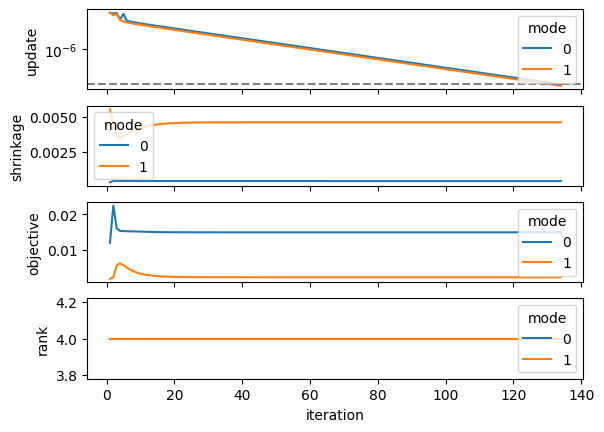

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

fig, axs = plt.subplots(4,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])
sns.lineplot(data=df, x='iteration', y='rank',hue='mode', ax=axs[3])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='F_tr', ax=axs[0])
    sns.lineplot(data=df, x=df.index, y='F_rt', ax=axs[1])

  0%|          | 0/256 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/cupy/linalg/_solve.py:169: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


,iteration,mode,update,shrinkage
0,0,0,inf,NaN
1,0,1,inf,NaN
2,1,0,1.402941e+00,0.0
3,1,1,8.956098e-01,0.0
4,2,0,8.351420e-02,0.0
5,2,1,5.797943e-03,0.0
6,3,0,1.610095e-03,0.0
7,3,1,1.574323e-04,0.0
8,4,0,4.837397e-05,0.0
9,4,1,4.947945e-06,0.0


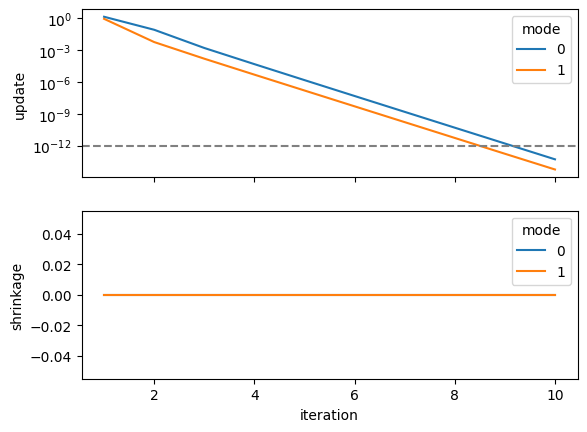

In [43]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
display(df)

fig, axs = plt.subplots( 2,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='mse', ax=axs[0])
    axs[0].set_yscale('log')
    sns.lineplot(data=df, x=df.index, y='err_cross_corr', ax=axs[1])
    axs[1].set_yscale('log')


In [37]:
import math
from hoda.util import center

X = tl.tensor(X)
G = hoda.transform(X)
X_approx = hoda.inv_transform(G)
err = X-X_approx


<Axes: >

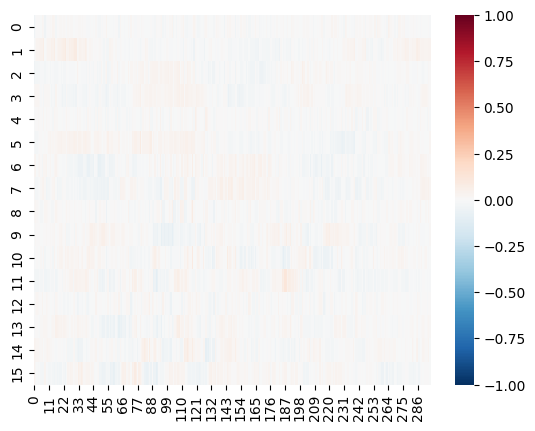

In [38]:
n_samples = X.shape[0]
G_flat = tl.to_numpy(G.reshape((n_samples, -1), order='F'), )
err_flat = tl.to_numpy(err.reshape((n_samples, -1), order='F'))
cross_corr = np.corrcoef(G_flat, err_flat, rowvar=False)
cross_corr = cross_corr[G_flat.shape[-1]:,:G_flat.shape[-1]].T
sns.heatmap(cross_corr,  cmap='RdBu_r', center=0, vmin=-1, vmax=1)

<Axes: >

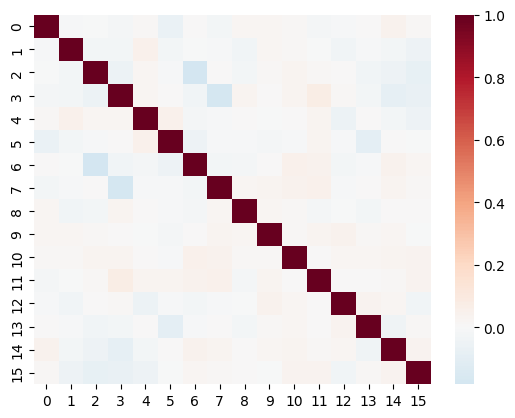

In [39]:
#G_cov = tl.tensordot(G.T, G, axes=1)/(n_samples-1)
G_flat = tl.to_numpy(G.reshape(n_samples, -1))
sns.heatmap(np.corrcoef(G_flat, rowvar=False),  cmap='RdBu_r', center=0)

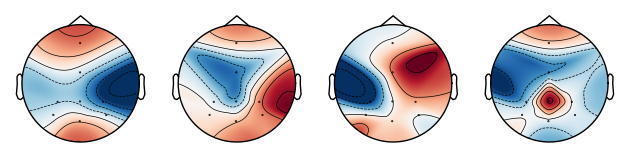

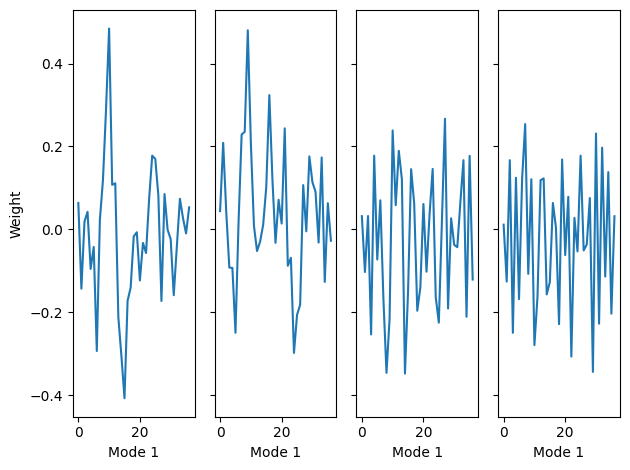

In [40]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4


n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

order = X.ndim-1
for k in range(1, order):
    n_row = int( np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
    for i in range(hoda.rank_[k]):
        w = tl.to_numpy(hoda.weights_[k][:,i])
        axs.flatten()[i].plot(w)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Weight');


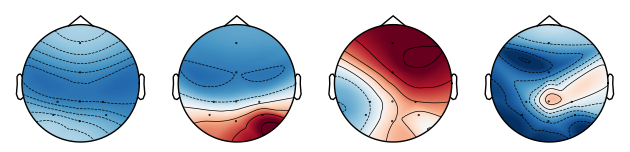

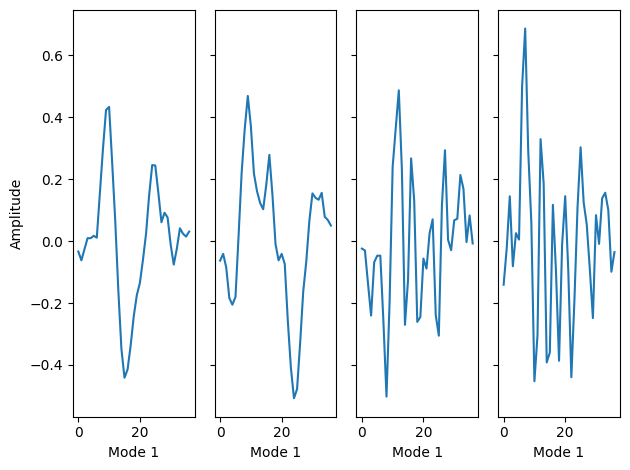

In [41]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

for k in range(1, order):
    n_row = int(np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(
        n_row, n_col, 
        layout='tight', 
        sharex=True,
        sharey=True
    )
    A = hoda.aps_[k]
    for i in range(hoda.rank_[k]):
        a = tl.to_numpy(A[:,i])
        axs.flatten()[i].plot(a)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Amplitude');

In [29]:
Xt = hoda.transform(X)

[[1.82390577e-37 1.24383814e-01 7.52053337e-05 1.83538777e-03]
 [5.02751794e-36 4.35198138e-82 7.87490526e-04 2.61720682e-02]
 [1.83648237e-02 8.27794427e-06 1.32569185e-09 1.22579076e-09]
 [6.07955632e-35 6.68994974e-02 8.09024183e-08 6.47765122e-05]]


<BarContainer object of 4 artists>

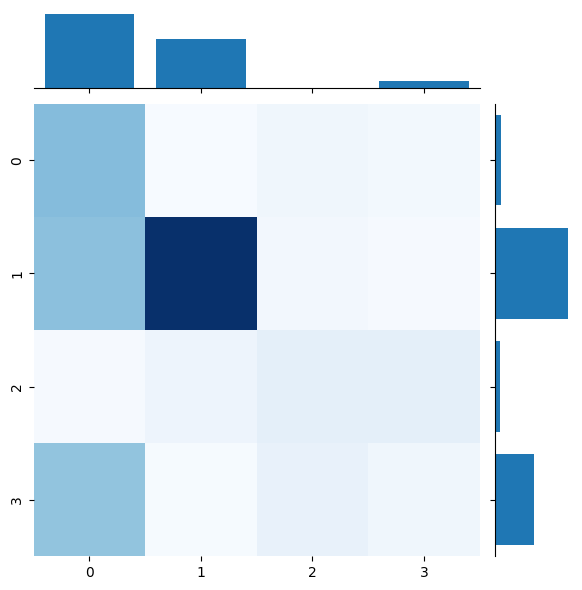

In [30]:
from hoda.util import f_multiway, f_oneway

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)
print(p)
g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint,
            #mask=p>0.5/p.size,
            cbar=False,
            cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)



<Axes: >

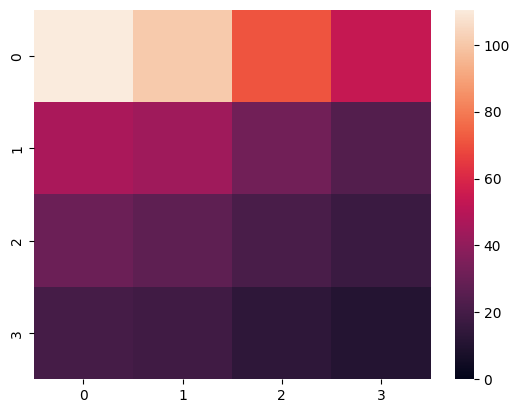

In [31]:
_,Xt_centered = center(Xt, y)
norm = tl.norm(Xt_centered, axis=0)
sns.heatmap(tl.to_numpy(norm), vmin=0)

In [32]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(5400, 16)

      index       PC1       PC2      label
0         0 -1.358767 -0.075286  NonTarget
1         1 -0.967922 -0.540797  NonTarget
2         2  1.876671  1.537616  NonTarget
3         3 -1.205392 -0.423547  NonTarget
4         4  0.118746 -0.421439  NonTarget
...     ...       ...       ...        ...
5395   5395 -0.138825  3.689747  NonTarget
5396   5396  0.080518  0.388036  NonTarget
5397   5397  3.563186 -0.179189  NonTarget
5398   5398 -0.079543  0.051613  NonTarget
5399   5399 -1.656196 -3.301578  NonTarget

[5400 rows x 4 columns]


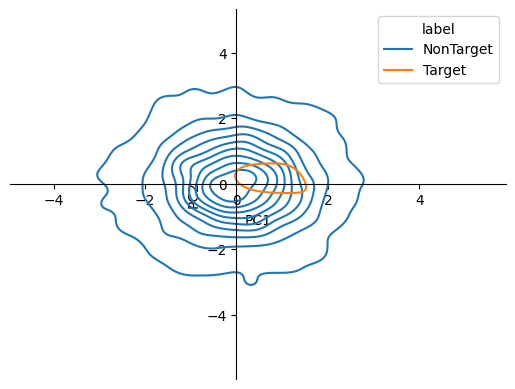

In [33]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    #sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


In [34]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.apply_baseline((None,0)).plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

ValueError: Baseline interval is only one sample. Use `baseline=(0, 0)` if this is desired.

In [ ]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.apply_baseline((None,0)).plot_joint(title=cls,
                              **joint_args
                             )
    else:
        evoked_rec.plot(**ts_args)

In [ ]:
from mne import combine_evoked, EvokedArray

contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(
    **joint_args
)


means_rec = hoda.inv_transform(hoda.transform(hoda.means_))
contrast_rec = means_rec[1]-means_rec[0]
contrast_rec = EvokedArray(tl.to_numpy(contrast_rec), epochs.info, epochs.tmin)
_ = contrast_rec.apply_baseline((None,0)).plot_joint(
    **joint_args
)

In [ ]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.apply_baseline((None,0)).plot_joint(
    **joint_args
)